In [ ]:
# todos
# include soil moisture in the model
# add Ecosystem_type and Biome as labels in the popups in the map

# possible future additions
# model Q10 based on soil type and soil carbon

# notes
# At the global scale, there is consensus that Q10 decreases from polar to temperate to tropical regions (Bekku et al., 2003; Zhou et al., 2009a) and that it is inversely correlated with mean annual temperature (Peng et al., 2009; Zheng et al., 2009). 

In [ ]:
import zipfile
import h5netcdf
import h5py

import pandas as pd
import numpy as np
import cdsapi

import xarray as xr
import hvplot.xarray
import holoviews as hv
import hvplot.pandas
import geoviews as gv
hv.extension("bokeh")
gv.extension("bokeh")  # Also enable geoviews

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,  mean_absolute_error
from scipy.spatial import KDTree
from modsim import *

In [ ]:

# Open the zip file and extract moisture dataset

with zipfile.ZipFile("historical_data_moisture.zip", 'r') as zip_ref:
    # List all the file names in the zip archive
    file_names = zip_ref.namelist()

    for file_name in file_names:
    # Open the nc file in the zip archive
        if ".nc" in file_name:
            print(f"Data file in the zip archive: {file_name}")
            
            # Read directly from zip
            with zip_ref.open(file_name) as file:
                historical_moisture_dataset = xr.open_dataset(file, engine="h5netcdf").load()  # or engine="scipy"
                #df = dataset.to_dataframe().reset_index()
            print(f"Processed file: {file_name}")

print("File processed")


2026-02-21 20:23:54,187 INFO Request ID is 8f29d63e-9a30-4c3b-a8bc-cf509ec00499
2026-02-21 20:23:54,261 INFO status has been updated to accepted
2026-02-21 20:24:03,755 INFO status has been updated to running
2026-02-21 20:24:28,809 INFO status has been updated to successful


264d844c46047ab44dd6268b6fddb085.zip:   0%|          | 0.00/37.4M [00:00<?, ?B/s]

'historical_data_moisture.zip'

In [226]:
# Open the zip files and extract datasets

# Define the path to the zip file
zip_file_path = ["ssp126_data.zip", "ssp245_data.zip", "ssp585_data.zip"]

datasets = []

# Open the zip file
for zip_data in zip_file_path:
    with zipfile.ZipFile(zip_data, 'r') as zip_ref:
        # List all the file names in the zip archive
        file_names = zip_ref.namelist()

        for file_name in file_names:
        # Open the nc file in the zip archive
            if ".nc" in file_name:
                print(f"Data file in the zip archive: {file_name}")
                
                # Read directly from zip
                with zip_ref.open(file_name) as file:
                    dataset = xr.open_dataset(file, engine="h5netcdf").load()  # or engine="scipy"
                    #df = dataset.to_dataframe().reset_index()
                    datasets.append(dataset)
                print(f"Processed file: {file_name}")

print("Files processed")

# Define the path to the zip file
zip_file_path = ["ssp126_data_temperature.zip", "ssp245_data_temperature.zip", "ssp585_data_temperature.zip"]  # Replace with your actual zip file path

temperature_datasets = []

# Open the zip file
for zip_data in zip_file_path:
    with zipfile.ZipFile(zip_data, "r") as zip_ref:
        # List all the file names in the zip archive
        file_names = zip_ref.namelist()

        for file_name in file_names:
        # Open the nc file in the zip archive
            if ".nc" in file_name:
                print(f"Data file in the zip archive: {file_name}")
                
                # Read directly from zip
                with zip_ref.open(file_name) as file:
                    dataset = xr.open_dataset(file, engine="h5netcdf").load()  # or engine="scipy"
                    #df = dataset.to_dataframe().reset_index()
                    temperature_datasets.append(dataset)
                print(f"Processed file: {file_name}")

print("Files processed")

# print(datasets[2].info()) # for checking the structure of the dataset

Data file in the zip archive: mrsos_Lmon_CESM2_ssp126_r4i1p1f1_gn_20150115-20991215.nc
Processed file: mrsos_Lmon_CESM2_ssp126_r4i1p1f1_gn_20150115-20991215.nc
Data file in the zip archive: mrsos_Lmon_CESM2_ssp245_r4i1p1f1_gn_20150115-20991215.nc
Processed file: mrsos_Lmon_CESM2_ssp245_r4i1p1f1_gn_20150115-20991215.nc
Data file in the zip archive: mrsos_Lmon_CESM2_ssp585_r4i1p1f1_gn_20150115-20991215.nc
Processed file: mrsos_Lmon_CESM2_ssp585_r4i1p1f1_gn_20150115-20991215.nc
Files processed
Data file in the zip archive: tas_Amon_CESM2_ssp126_r4i1p1f1_gn_20150115-20991215.nc
Processed file: tas_Amon_CESM2_ssp126_r4i1p1f1_gn_20150115-20991215.nc
Data file in the zip archive: tas_Amon_CESM2_ssp245_r4i1p1f1_gn_20150115-20991215.nc
Processed file: tas_Amon_CESM2_ssp245_r4i1p1f1_gn_20150115-20991215.nc
Data file in the zip archive: tas_Amon_CESM2_ssp585_r4i1p1f1_gn_20150115-20991215.nc
Processed file: tas_Amon_CESM2_ssp585_r4i1p1f1_gn_20150115-20991215.nc
Files processed


In [230]:
scenario = "ssp2_4_5"  # Change this to "ssp1_2_6", "ssp2_4_5", or "ssp5_8_5" to select the scenario

def select_scenario(scenario):
    if scenario == "ssp1_2_6":
        return temperature_datasets[0], datasets[0]
    elif scenario == "ssp2_4_5":
        return temperature_datasets[1], datasets[1]
    elif scenario == "ssp5_8_5":
        return temperature_datasets[2], datasets[2]
    else:
        raise ValueError('Invalid scenario. Please choose from "ssp1_2_6", "ssp2_4_5", or "ssp5_8_5".')

min_val_temp = select_scenario(scenario)[0]["tas"].min().values
max_val_temp = select_scenario(scenario)[0]["tas"].max().values
min_val_m = select_scenario(scenario)[1]["mrsos"].min().values
max_val_m = select_scenario(scenario)[1]["mrsos"].max().values
min_val_hm = historical_moisture_dataset["mrsos"].min().values
max_val_hm = historical_moisture_dataset["mrsos"].max().values

temperature_dataset = select_scenario(scenario)[0]
moisture_dataset = select_scenario(scenario)[1]

# plotting the data from the Copernicus Climate Data Store (CDS) using hvplot and xarray
temp = temperature_dataset["tas"].hvplot(x="lon",
                                    y="lat",
                                    groupby="time",
                                    cmap="RdBu_r", 
                                    frame_width=600,
                                    frame_height=400, 
                                    clim=(min_val_temp, max_val_temp))

moisture = moisture_dataset["mrsos"].hvplot(x="lon",
                                        y="lat",
                                        groupby="time",
                                        cmap="YlGnBu",
                                        frame_width=600,
                                        frame_height=400,
                                        clim=(min_val_m, max_val_m),
                                        alpha=0.7) # Adjust alpha for better visibility

historical_moisture = historical_moisture_dataset["mrsos"].hvplot(x="lon",
                                        y="lat",
                                        groupby="time",
                                        cmap="YlGnBu",
                                        frame_width=600,
                                        frame_height=400,
                                        clim=(min_val_hm, max_val_hm),
                                        alpha=0.7) # Adjust alpha for better visibility

#temp
#moisture #uncomment to plot moisture time series
historical_moisture

BokehModel(combine_events=True, render_bundle={'docs_json': {'918ea75f-733c-4d20-8b1c-6c4741fd2575': {'version…

In [ ]:
#getting the data from the SoilRespirationDataBase (SRDB) and storing as a pandas dataframe
Rs_data = pd.read_csv("srdb-20250503a/srdb-data.csv")
equations_data = pd.read_csv("srdb-20250503a/srdb-equations.csv")
#study_data = pd.read_csv("srdb-20250503a/srdb-studies.csv")

df = Rs_data.merge(equations_data, on="Record_number", how="inner")
df.loc[df["Longitude"] < 0, "Longitude"] += 360
df = df.dropna(subset=["Latitude", "Longitude", "Biome", "Ecosystem_type", "Rs_annual", "MAT"]) # for dropping rows with missing values in the specified columns
df["r"] = df["Rs_annual"]/5 # for calculating the radius of the circles in the map based on the annual soil respiration rates

df = df[["Record_number", "Study_number", "Latitude", "Longitude", "Biome", "Ecosystem_type", "Rs_annual", "r", "Study_midyear",
         "MAT"
         #,"Q10_0_10", "Q10_5_15", "Q10_10_20", "Q10_0_20", "Q10_other1", "Q10_other1_temp_min", "Q10_other1_temp_max"
         ]]                 #selecting only the columns relevant for modeling
df = df[(df['Rs_annual'] > 0) & (df['Rs_annual'] < 5000)]
df = df[(df['Study_midyear'] < 2015)]

biomes = ["Boreal", "Temperate", "Tropical"] #list biomes of interest for study

forests = df[df["Biome"].isin(biomes) & df["Ecosystem_type"].isin(["Forest"])]

/var/folders/xv/jsfbtk_97xv2bbw17vqflc1w0000gn/T/ipykernel_89183/2230774555.py:2: DtypeWarning:

Columns (0: Duplicate_record, 1: Rs_annual_err, 2: C_soildepth) have mixed types. Specify dtype option on import or set low_memory=False.



In [96]:
# overlaying the data from the SRDB on a map using hvplot, geopandas, and geoviews
plot = forests.hvplot.points(
          x='Longitude',
          y='Latitude', 
          c='Biome',          # Color by biome
          cmap='Dark2',       # select colormap (viridis, magma, inferno, etc.)
          size='r',           # Size by magnitude (using square root for better scaling)
          #tiles='OSM',       # Add OpenStreetMap basemap
          alpha=0.4,          # Adjust point transparency
          legend='left',      # choose from ['top_right', 'top_left', 'bottom_left', 'bottom_right', 'right', 'left', 'top', 'bottom']
          frame_width=600,
          frame_height=400,
          #groupby='year'     # Creates slider for animation
     )

temp * plot

#moisture * plot

BokehModel(combine_events=True, render_bundle={'docs_json': {'5d000ad6-a146-45fb-9049-da06c81f501d': {'version…

In [97]:
Rs_plot = forests.hvplot.points(
          x='Longitude',
          y='Latitude', 
          c='Rs_annual',           # set color by magnitude of annual soil respiration
          cmap='magma_r',
          size='r',                # Size by magnitude
          #tiles='OSM',            # Add OpenStreetMap basemap
          alpha=0.6,               # Adjust transparency
          frame_width=600,
          frame_height=400
     #     groupby='year'           # Creates slider for animation
     )

temp * Rs_plot 

BokehModel(combine_events=True, render_bundle={'docs_json': {'90c9b11d-6320-40a8-b0f1-238ee4233bb3': {'version…

In [ ]:
#Locate nearest neighbors to on latitude and longitude grid of CDS data for each individual data point

def get_location(i):
    query_point = [forests["Latitude"].iloc[i], forests["Longitude"].iloc[i]]
    return query_point

lat_array = (temperature_dataset["lat"]).values
lon_array = (temperature_dataset["lon"]).values

lat_grid, lon_grid = np.meshgrid(lat_array, lon_array)
grid = np.column_stack([lat_grid.ravel(), lon_grid.ravel()])                        # Flatten the meshgrid and stack coordinates for KDTree

tree = KDTree(grid)                                                                 # Instantiate K Nearest Neighbor searhc

lat_nn = []
lon_nn = []
biome_nn = []
record_nn = []
year_nn = []

for i in range(len(forests["Latitude"])):
    #distance, index = tree.query(get_location(i))
    biome_nn.append(forests["Biome"].iloc[i])
    biome_nn.append(forests["Biome"].iloc[i])
    record_nn.append(forests["Record_number"].iloc[i].astype(int))
    record_nn.append(forests["Record_number"].iloc[i].astype(int))
    year_nn.append(forests["Study_midyear"].iloc[i].astype(int))
    year_nn.append(forests["Study_midyear"].iloc[i].astype(int))
    lat_nn.append(grid[tree.query(get_location(i))[1]][0])                                                        # Add latitude and longitude values to list
    lon_nn.append(grid[tree.query(get_location(i))[1]][1])

temp_df = points.to_dataframe().reset_index()
points = temperature_dataset.sel(lat=xr.DataArray(lat_nn), lon=xr.DataArray(lon_nn), method='nearest')            # select respective times and temperatures for the grid locations
temp_df = points.to_dataframe().reset_index()[["time", "tas", "lat", "lon"]]

temp_df["tas"] = temp_df["tas"] - 273.15                                                                          # converting from Kelvin to degrees Celsius
temp_df["Biome"] = biome_nn * len(temp_df["time"].unique())
temp_df["Record_number"] = record_nn * len(temp_df["time"].unique())
temp_df["year"] = pd.to_datetime(temp_df['time'].astype(str)).dt.year
temp_df = temp_df[::2].reset_index(drop=True)                                                                     # every other row is a duplicate, remove superfluous data    

moisture_points = moisture_dataset.sel(lat=xr.DataArray(lat_nn), lon=xr.DataArray(lon_nn), method='nearest')   # select respective times and temperatures for the grid locations
moisture_df = moisture_points.to_dataframe().reset_index()[["time", "mrsos", "lat", "lon"]]
moisture_df["Record_number"] = record_nn * len(moisture_df["time"].unique())
moisture_df = moisture_df[::2].reset_index(drop=True)    

temp_df = pd.concat([temp_df, moisture_df[['mrsos']]], axis=1)

hist_moisture_points = historical_moisture_dataset.sel(lat=xr.DataArray(lat_nn), lon=xr.DataArray(lon_nn), method='nearest')   # select respective times and temperatures for the grid locations
hist_moisture_df = hist_moisture_points.to_dataframe().reset_index()[["time", "mrsos", "lat", "lon"]]
hist_moisture_df["Record_number"] = record_nn * len(hist_moisture_df["time"].unique())
hist_moisture_df["year"] = pd.to_datetime(hist_moisture_df['time'].astype(str)).dt.year
hist_moisture_df["study_year"] = year_nn * len(hist_moisture_df["time"].unique())
hist_moisture_df = hist_moisture_df[hist_moisture_df['year'] == hist_moisture_df['study_year']]
hist_moisture_df = hist_moisture_df[["mrsos", "lat", "lon", "study_year", "Record_number"]]

forests["nn_lat"] = lat_nn
forests["nn_lon"] = lon_nn

nnplot = forests.hvplot.points(
     x='nn_lon',
     y='nn_lat', 
     c='white',
     size='3',                 
     #tiles='OSM',         
     alpha=0.4,                 
     legend='left',             # choose from ['top_right', 'top_left', 'bottom_left', 'bottom_right', 'right', 'left', 'top', 'bottom']
     frame_width=600,
     frame_height=400
#     groupby='year'
)

temp * plot * nnplot            # Checking visually how well the fit for the nearest neighbors on the grid is


BokehModel(combine_events=True, render_bundle={'docs_json': {'feaa9925-29fb-43f8-9ca3-85d16edb5132': {'version…

In [267]:
hist_moisture_df = hist_moisture_df.groupby(["lat", "lon", "Record_number","study_year"])['mrsos'].mean().reset_index().dropna()

forests = forests.merge(hist_moisture_df, on="Record_number", how="inner")

hplot = hist_moisture_df.hvplot.points(
    x='lon',
    y='lat', 
    c='mrsos',   
    alpha=0.6,                 
    legend='left',             # choose from ['top_right', 'top_left', 'bottom_left', 'bottom_right', 'right', 'left', 'top', 'bottom']
    frame_width=600,
    frame_height=400,
    #groupby='study_year'
)
hplot

:Points   [lon,lat]   (mrsos)

In [ ]:
def Rs_func_moisture(T, M, R_base, Q10_base, T_base, M_base, beta):
    """T = temperature, M = moisture"""
    return R_base * (Q10_base ** ((T - T_base) / 10)) * (1 / (1 + np.exp(-beta * (M - M_base))))



Fitted parameters for Boreal biome: [716.45293742   1.4555196   12.11543626]
Boreal: Test MAE=192.6, R²=0.053


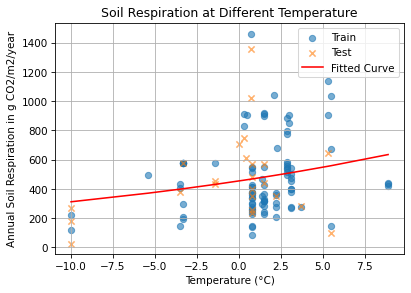

Fitted parameters for Temperate biome: [811.81973056   1.23230748   9.98709369]
Temperate: Test MAE=272.8, R²=0.070


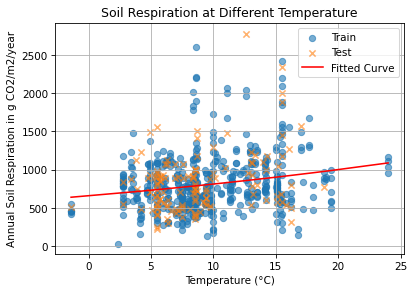

Fitted parameters for Tropical biome: [878.09949118   1.16834456  12.4225833 ]
Tropical: Test MAE=494.8, R²=0.012


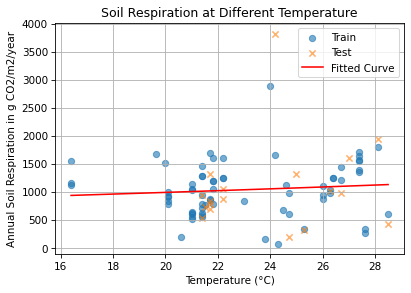

In [325]:
# To model soil respiration at the individual sites, 

def Rs_func(T, R_base, Q10_base, T_base):
    return R_base * (Q10_base ** ((T-T_base)/10))

func_choice = Rs_func

tropical = forests[(forests["Biome"] == "Tropical")]
temperate = forests[(forests["Biome"] == "Temperate")]
boreal = forests[(forests["Biome"] == "Boreal")]

R_parameters = []

for i, biome in enumerate([boreal, temperate, tropical]):
    #biome = biome[(biome['Rs_annual'] >= biome['Rs_annual'].quantile(0.25)) & (biome['Rs_annual'] <= biome['Rs_annual'].quantile(0.75))] # optional data cleaning step to remove outliers

    train, test = train_test_split(biome, test_size=0.2, random_state=42)       # Do a train/test split to keep some data for validation later

    popt, pcov = curve_fit(func_choice, train["MAT"], train["Rs_annual"],
                           p0=(1000, 2, 5),
                           bounds=([0, 1, -10],                                 # set lower bounds
                                   [10000, 5, 30]))                             # and upper bounds
    
    # popt, pcov = curve_fit(Rs_func_moisture, train["MAT"], train["mrsos_y"], train["Rs_annual"],
    #                        p0=(1000, 2, 5, 25, 0.1),
    #                        bounds=([0, 1, -10, 10, 0],                                 # set lower bounds
    #                                [10000, 5, 30, 60, 10]))                             # and upper bounds
    
    print(f"Fitted parameters for {biomes[i]} biome:", popt)    

    y = func_choice(np.sort(train["MAT"]), *popt)
    #validation with mean absolute error
    y_pred = func_choice(test["MAT"], *popt)
    mae = mean_absolute_error(test["Rs_annual"], y_pred)

    # Validate on test data
    mae_test = mean_absolute_error(test["Rs_annual"], y_pred)
    r2_test = r2_score(test["Rs_annual"], y_pred)

    print(f"{biomes[i]}: Test MAE={mae_test:.1f}, R²={r2_test:.3f}")

    plt.scatter(train["MAT"], train["Rs_annual"], label='Train', alpha=0.6)
    plt.scatter(test["MAT"], test["Rs_annual"], label='Test', alpha=0.6, marker='x')
    plt.plot(np.sort(train["MAT"]), y, 'r-', label="Fitted Curve")

    # plt.xlim(-10, 30)
    # plt.ylim(0, 4000)
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Annual Soil Respiration in g CO2/m2/year')
    plt.title('Soil Respiration at Different Temperature')
    plt.legend()
    plt.grid()
    plt.show()

    R_parameters.append([biomes[i], popt])

R_boreal_params= R_parameters[0][1]
R_temperate_params= R_parameters[1][1]
R_tropical_params= R_parameters[2][1]

In [326]:
# Model performance is compared to a machine learning regressor algorithm as a benchmark

random_states = []
for i, biome_df in enumerate([boreal, temperate, tropical]):
    X = biome_df[["MAT", "mrsos_y"]].values
    y = biome_df["Rs_annual"].values
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=34)

    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    print(f"Random forest regressor R² for {biomes[i]} biomes: {r2_score(y_test, y_pred):.3f}")



Random forest regressor R² for Boreal biomes: 0.725
Random forest regressor R² for Temperate biomes: 0.599
Random forest regressor R² for Tropical biomes: 0.557


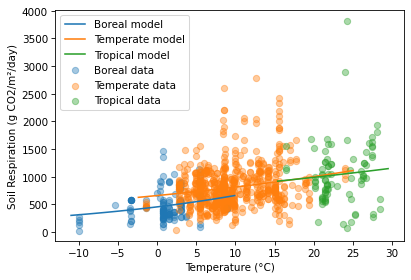

In [327]:
T_boreal = np.linspace(boreal["MAT"].min()-1,
                       (boreal["MAT"].max()+1),
                       len(boreal["MAT"]))
T_temperate = np.linspace(temperate["MAT"].min()-1,
                          (temperate["MAT"].max()+1),
                          len(temperate["MAT"]))
T_tropical = np.linspace(tropical["MAT"].min()-1,
                         (tropical["MAT"].max()+1),
                         len(tropical["MAT"]))

R_boreal = Rs_func(T_boreal, *R_boreal_params)
R_temperate = Rs_func(T_temperate, *R_temperate_params)
R_tropical = Rs_func(T_tropical, *R_tropical_params)

R_boreal_data = boreal["Rs_annual"]
R_temperate_data = temperate["Rs_annual"]
R_tropical_data = tropical["Rs_annual"]

# Plot
plt.plot(T_boreal, R_boreal, label="Boreal model")
plt.plot(T_temperate, R_temperate, label="Temperate model")
plt.plot(T_tropical, R_tropical, label="Tropical model")

plt.scatter(boreal["MAT"], R_boreal_data, label="Boreal data", linestyle = "None", alpha= 0.4)
plt.scatter(temperate["MAT"], R_temperate_data, label="Temperate data", linestyle = "None", alpha= 0.4)
plt.scatter(tropical["MAT"], R_tropical_data, label="Tropical data", linestyle = "None", alpha= 0.4)

plt.xlabel('Temperature (°C)')
plt.ylabel('Soil Respiration (g CO2/m²/day)')
plt.legend()
plt.show()

In [218]:
# modeling soil respiration using the data from the CDS and SRDB, and plotting the results using hvplot
# selecting nearest neighbor temperature from Temperature dataset

Rs_monthly_pred = []
params_list = [R_boreal_params, R_temperate_params, R_tropical_params]

for i in range(len(temp_df)):
    if temp_df["Biome"][i]== "Boreal":
        Rs_pred = Rs_func(temp_df["tas"][i], *params_list[0])           # generate soil repspiration predictions based on nearest neighbor temperature and boreal model parameters
        Rs_monthly_pred.append(Rs_pred/12)                               # divide by 12 to get monthly soil respiration predictions
    elif temp_df["Biome"][i]== "Temperate":
        Rs_pred = Rs_func(temp_df["tas"][i], *params_list[1])           # generate soil repspiration predictions based on nearest neighbor temperature and temperate model parameters
        Rs_monthly_pred.append(Rs_pred/12)
    elif temp_df["Biome"][i]== "Tropical":
        Rs_pred = Rs_func(temp_df["tas"][i], *params_list[2])           # generate soil repspiration predictions based on nearest neighbor temperature and tropical model parameters
        Rs_monthly_pred.append(Rs_pred/12)
    
temp_df["Rs_predictions"] = Rs_monthly_pred

In [219]:
annual_predictions = temp_df.groupby(["lat", "lon", "Record_number","year", "Biome"])['Rs_predictions'].sum().reset_index()

mean_annual_predictions = annual_predictions.groupby(["year", "Biome"])['Rs_predictions'].mean().reset_index()

In [220]:
temp2 = temp_df.hvplot.points(x='lon',
                        y='lat',
                        c = "Rs_predictions",
                        groupby='time',
                        cmap='RdBu_r', 
                        size = "Rs_predictions",
                        frame_width=600,
                        frame_height=400, 
                        #clim=(min_val_temp, max_val_temp)
                        )

temp * temp2

BokehModel(combine_events=True, render_bundle={'docs_json': {'eaf3dd3c-3d7d-46d9-8207-41786874f3b5': {'version…

In [221]:
temp3 = annual_predictions.hvplot.points(x='lon',
                        y='lat',
                        c = "Biome",
                        groupby='year',
                        #cmap='RdBu_r', 
                        size = "Rs_predictions",
                        tiles='OSM',            # Add OpenStreetMap basemap
                        frame_width=600,
                        frame_height=400, 
                        #clim=(min_val_temp, max_val_temp)
                        )

temp3

BokehModel(combine_events=True, render_bundle={'docs_json': {'08bd533b-832e-420f-ac87-3fc2bc4aa518': {'version…

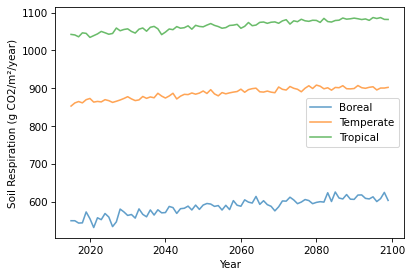

In [222]:
for biome in biomes:
    data = mean_annual_predictions[mean_annual_predictions["Biome"]== biome] 
    plt.plot(data["year"], data["Rs_predictions"],
                label= f"{biome}",
                #s = 0.9,
                alpha= 0.7)

plt.xlabel('Year')
plt.ylabel('Soil Respiration (g CO2/m²/year)')
plt.legend()
plt.show()

    Plants  Atmosphere   Soils  Fossil_Fuels  Earth_Crust  Surface_Ocean  \
0    560.0       750.0  1500.0       10000.0  100000000.0          725.0   
1    560.9       753.9  1500.1        9992.3  100000000.0          727.8   
2    561.8       757.8  1500.2        9984.6  100000000.0          730.6   
3    562.7       761.7  1500.3        9976.9  100000000.0          733.4   
4    563.6       765.6  1500.4        9969.2  100000000.0          736.2   
..     ...         ...     ...           ...          ...            ...   
71   623.9      1026.9  1507.1        9453.3  100000000.0          923.8   
72   624.8      1030.8  1507.2        9445.6  100000000.0          926.6   
73   625.7      1034.7  1507.3        9437.9  100000000.0          929.4   
74   626.6      1038.6  1507.4        9430.2  100000000.0          932.2   
75   627.5      1042.5  1507.5        9422.5  100000000.0          935.0   

    Deep_and_Abyssal_Ocean  
0                  37275.0  
1                  37275.0  


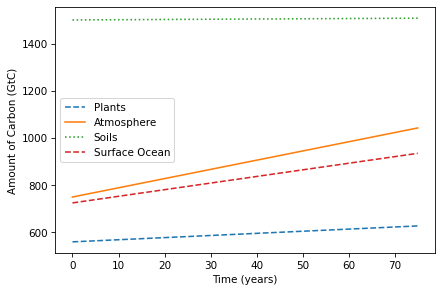

In [145]:
#modeling soil respiration using the data from the CDS and SRDB, and plotting the results using matplotlib

tc = 2           # time between contacts in days 
tr = 5             # recovery time in days

beta = 1 / tc      # contact rate in per day
gamma = 1 / tr     # recovery rate in per day
    
def make_system(beta, gamma, absolute=True, t_end=75):
    init = State(Plants=560, Atmosphere=750, Soils=1500, Fossil_Fuels=10000, Earth_Crust=100000000, Surface_Ocean=725, Deep_and_Abyssal_Ocean=37275)
    if absolute == False:
        init /= init.sum()

    return System(init=init, t_end=t_end,
                  beta=beta, gamma=gamma)

system = make_system(beta, gamma)
show(system)

def update_func(t, state, system):
    Plants, Atmosphere, Soils, Fossil_Fuels, Earth_Crust, Surface_Ocean, Deep_and_Abyssal_Ocean = state.Plants, state.Atmosphere, state.Soils, state.Fossil_Fuels, state.Earth_Crust, state.Surface_Ocean, state.Deep_and_Abyssal_Ocean

    Litterfall = 59
    Photosynthesis = 120
    Plant_Respiration = 59
    Volcanic_Eruptions = 0.1
    Burning_Fossil_Fuels = 7.7
    Soil_Respiration = 58
    Rivers = 0.9
    Burial_to_Sediments = 0.1
    Deforestation = 1.1
    Ocean_Uptake = 92
    Ocean_Loss = 90
    
    Plants -= Litterfall
    Soils += Litterfall

    Plants += Photosynthesis
    Atmosphere -= Photosynthesis

    Plants -= Plant_Respiration
    Atmosphere += Plant_Respiration

    Earth_Crust -= Volcanic_Eruptions
    Atmosphere += Volcanic_Eruptions

    Fossil_Fuels -= Burning_Fossil_Fuels
    Atmosphere += Burning_Fossil_Fuels

    Soils -= Soil_Respiration
    Atmosphere += Soil_Respiration

    Soils -= Rivers
    Surface_Ocean += Rivers
    Surface_Ocean -= Burial_to_Sediments
    Earth_Crust += Burial_to_Sediments

    Plants -= Deforestation
    Atmosphere += Deforestation

    Atmosphere -= Ocean_Uptake
    Surface_Ocean += Ocean_Uptake

    Surface_Ocean -= Ocean_Loss
    Atmosphere += Ocean_Loss
    
    return State(Plants=Plants, Atmosphere=Atmosphere, Soils=Soils, Fossil_Fuels=Fossil_Fuels, Earth_Crust=Earth_Crust, Surface_Ocean=Surface_Ocean, Deep_and_Abyssal_Ocean=Deep_and_Abyssal_Ocean)

state = update_func(0, system.init, system)
show(state)


def run_simulation(system, update_func):
    frame = TimeFrame(columns=system.init.index)
    frame.loc[0] = system.init
    
    for t in range(0, system.t_end):
        frame.loc[t+1] = update_func(t, frame.loc[t], system)
    
    return frame

results = run_simulation(system, update_func)
print(results)

def plot_results(Plants, Atmosphere, Soils, Surface_Ocean):
    Plants.plot(style='--', label='Plants')
    Atmosphere.plot(style='-', label='Atmosphere')
    Soils.plot(style=':', label='Soils')
    Surface_Ocean.plot(style='--', label='Surface Ocean')
    decorate(xlabel='Time (years)',
                ylabel='Amount of Carbon (GtC)')
             
plot_results(results.Plants, results.Atmosphere, results.Soils, results.Surface_Ocean)
